# Practice 16 — Advanced CNN

**모던 CNN의 핵심 기법**을 비교 실험으로 학습합니다. 기본 2-layer CNN을 출발점으로, 한 번에 한 가지씩 추가하며 효과를 격리합니다.

| 섹션 | 내용 |
|------|------|
| 3-1 | 얕은 vs 깊은 (깊이 효과) |
| 3-2 | 깊은 vs 깊은 + BatchNorm |
| 3-3 | 깊은+BN vs 깊은+BN+Dropout |
| 4 | 증강 없음 vs RandomCrop + HorizontalFlip |
| 5 | Custom CNN 시각화 — 학습된 필터·feature map |
| 6 | Pretrained ResNet18 fine-tuning → ~89% |
| 7 | ResNet18 시각화 — 사전학습 필터 (Gabor/엣지/색 검출기) |
| 8 | 정리 |

**데이터셋:** CIFAR-10 (32x32 컬러, 10클래스) — 처음부터 끝까지 일관.

**옵티마이저:** SGD(lr=0.01, momentum=0.9). 모델 간 차이가 명확히 드러나도록 동일 설정.


In [1]:
# Windows + conda 환경에서 torch와 torchvision 동시 로드 시 OpenMP 충돌 회피
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# GPU 자동 선택
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('device:', device)


torch: 2.6.0+cu124
torchvision: 0.21.0+cu124
device: cuda


---
# 1. Conv-BN-ReLU 블록

BatchNorm을 **2D 텐서 (이미지)** 에 맞게 확장한 것이 `BatchNorm2d` 입니다. 채널별로 정규화합니다.

$$\hat{x}_{n,c,h,w} = \frac{x_{n,c,h,w} - \mu_c}{\sqrt{\sigma_c^2 + \epsilon}}, \qquad y_{n,c,h,w} = \gamma_c\,\hat{x}_{n,c,h,w} + \beta_c$$

모던 CNN의 표준 빌딩 블록 패턴:

```
Conv2d → BatchNorm2d → ReLU
```

이번 노트북에서는 이 패턴이 학습에 어떤 영향을 주는지 비교 실험으로 확인합니다.


---
# 2. CIFAR-10 데이터 파이프라인

Custom Dataset + 기본 transform 으로 CIFAR-10 의 첫 10000장(train) / 2000장(test) 을 가져옵니다.

학습 절대 성능보다 **모델 간 상대 비교** 가 목적이므로 부분집합 사용. (전체 데이터를 쓰면 모든 모델이 90%+에 수렴해 차이가 흐릿해집니다.)


## 2-1. Custom Dataset

CIFAR-10 numpy 데이터를 감싸는 9줄짜리 표준 템플릿을 사용합니다.


In [2]:
# CIFAR-10 데이터를 감싸는 사용자 정의 Dataset (PyTorch 표준 구조 — 템플릿)
# (자세한 동작 원리는 후속 강의에서 다룹니다. 지금은 이 형태를 그대로 사용하세요.)
class CIFAR10Dataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X                        # numpy uint8 (N, 32, 32, 3)
        self.y = y                        # numpy int    (N,)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = Image.fromarray(self.X[idx])   # numpy -> PIL (transform 입력 형식)
        if self.transform is not None:
            img = self.transform(img)
        return img, self.y[idx]


## 2-2. 데이터 로드

In [3]:
# CIFAR-10 표준 정규화 통계
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2440, 0.2620)

# 기본 transform: ToTensor + Normalize
transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# CIFAR-10 다운로드 (numpy 형태로 직접 다루기 위해 transform 없이 로드)
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True)
cifar_test  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

# 첫 10000장 (train) / 2000장 (test) 만 사용
X_train = cifar_train.data[:10000]
y_train = np.array(cifar_train.targets[:10000])
X_test  = cifar_test.data[:2000]
y_test  = np.array(cifar_test.targets[:2000])

train_set = CIFAR10Dataset(X_train, y_train, transform=transform_basic)
test_set  = CIFAR10Dataset(X_test,  y_test,  transform=transform_basic)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

class_names = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Train: {len(train_set)} samples')
print(f'Test : {len(test_set)} samples')

Train: 10000 samples
Test : 2000 samples


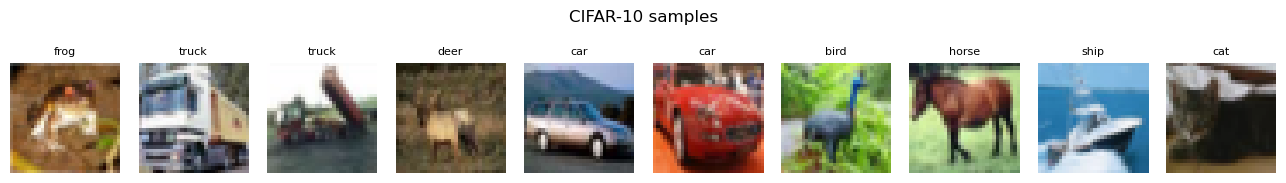

In [4]:
# 정규화된 텐서를 다시 표시 가능한 이미지로 되돌리는 헬퍼
mean_arr = np.array(CIFAR_MEAN)
std_arr  = np.array(CIFAR_STD)

def unnormalize(img_t):
    img = img_t.permute(1, 2, 0).numpy() * std_arr + mean_arr
    return np.clip(img, 0, 1)

# 샘플 10장 시각화
fig, axes = plt.subplots(1, 10, figsize=(13, 1.7))
for i in range(10):
    img_i, label_i = train_set[i]
    axes[i].imshow(unnormalize(img_i))
    axes[i].set_title(class_names[label_i], fontsize=8)
    axes[i].axis('off')
plt.suptitle('CIFAR-10 samples', y=1.05)
plt.tight_layout(); plt.show()


## 2-3. 학습 함수 정의

학습 루프를 두 함수로 묶어 둡니다.

| 함수 | 역할 |
|------|------|
| `train(model, train_loader, test_loader, optimizer, epochs, device)` | epochs 만큼 학습 + 매 epoch 평가, `(train_losses, test_losses, test_accs)` 반환 |
| `evaluate(model, loader, device)` | 한 번 평가, `(loss, accuracy)` 반환 |

추가로 비교 그래프를 그리는 `plot_compare` 헬퍼만 정의합니다.


In [5]:
# 학습 - epochs 만큼 학습 + 매 epoch 평가
# (train_losses, test_losses, test_accs) 반환
def train(model, train_loader, test_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses, test_accs = [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, count = 0.0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(Y_batch)
            count += len(Y_batch)
        train_loss = loss_sum / count
        test_loss, test_acc = evaluate(model, test_loader, device)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        print(f'  Epoch {epoch+1:2d}/{epochs}  train_loss={train_loss:.4f}  test_loss={test_loss:.4f}  test_acc={test_acc:.4f}')
    return train_losses, test_losses, test_accs


# 평가 - (loss, accuracy) 반환
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item() * len(Y_batch)
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
    return loss_sum / count, correct / count


# 비교 그래프 - 왼쪽: Loss (train 점선 + test 실선), 오른쪽: Test Accuracy
def plot_compare(r_a, r_b, label_a, label_b, title_prefix):
    tl_a, vl_a, va_a = r_a
    tl_b, vl_b, va_b = r_b
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(tl_a, '--', color='C0', alpha=0.5, label=f'{label_a} train')
    axes[0].plot(vl_a, '-',  color='C0', label=f'{label_a} test')
    axes[0].plot(tl_b, '--', color='C1', alpha=0.5, label=f'{label_b} train')
    axes[0].plot(vl_b, '-',  color='C1', label=f'{label_b} test')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title_prefix} - Loss (dashed=train, solid=test)')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].plot(va_a, 'o-', label=label_a)
    axes[1].plot(va_b, 's-', label=label_b)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
    axes[1].set_title(f'{title_prefix} - Test Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()


---
# 3. 비교 실험 — 깊이 / BN / Dropout 누적 효과

## 3-1. 깊이 효과: 얕은 vs 깊은

- **얕은 모델** (Shallow): Conv 2개
- **깊은 모델** (Deep): Conv 4개 + Kaiming 초기화 (깊을수록 좋은 초기화가 중요)

BN/Dropout 둘 다 없음. 깊이 효과만 격리.


In [6]:
# 얕은 CNN — 2-layer (P16과 동일 구조, 입력 채널만 3)
class CNN_Shallow(nn.Module):
    def __init__(self):
        super().__init__()
        # 입력: (N, 3, 32, 32)
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 32 -> 16
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 16 -> 8
        self.fc = nn.Linear(64 * 8 * 8, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.flatten(1)
        x = self.fc(x)
        return x


# 깊은 CNN — Conv 4개, BN/Dropout 없음, Kaiming(He) 초기화
class CNN_Deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 32 -> 16
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 16 -> 8
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 8 -> 4
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU())                        # 4 -> 4 (pool 없음)
        self.fc = nn.Linear(128 * 4 * 4, 10)
        # Kaiming(He) 초기화 — ReLU와 짝
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.flatten(1)
        x = self.fc(x)
        return x


print(f'Shallow params: {sum(p.numel() for p in CNN_Shallow().parameters()):,}')
print(f'Deep    params: {sum(p.numel() for p in CNN_Deep().parameters()):,}')


Shallow params: 60,362
Deep    params: 261,322


Training Shallow on cuda...


  Epoch  1/30  train_loss=1.8927  test_loss=1.6102  test_acc=0.4420


  Epoch  2/30  train_loss=1.4992  test_loss=1.5228  test_acc=0.4465


  Epoch  3/30  train_loss=1.3202  test_loss=1.3395  test_acc=0.5245


  Epoch  4/30  train_loss=1.1849  test_loss=1.2418  test_acc=0.5475


...

  Epoch 26/30  train_loss=0.0010  test_loss=2.4223  test_acc=0.6405


  Epoch 27/30  train_loss=0.0009  test_loss=2.4572  test_acc=0.6420


  Epoch 28/30  train_loss=0.0008  test_loss=2.4857  test_acc=0.6400


  Epoch 29/30  train_loss=0.0007  test_loss=2.5141  test_acc=0.6390


  Epoch 30/30  train_loss=0.0007  test_loss=2.5348  test_acc=0.6415


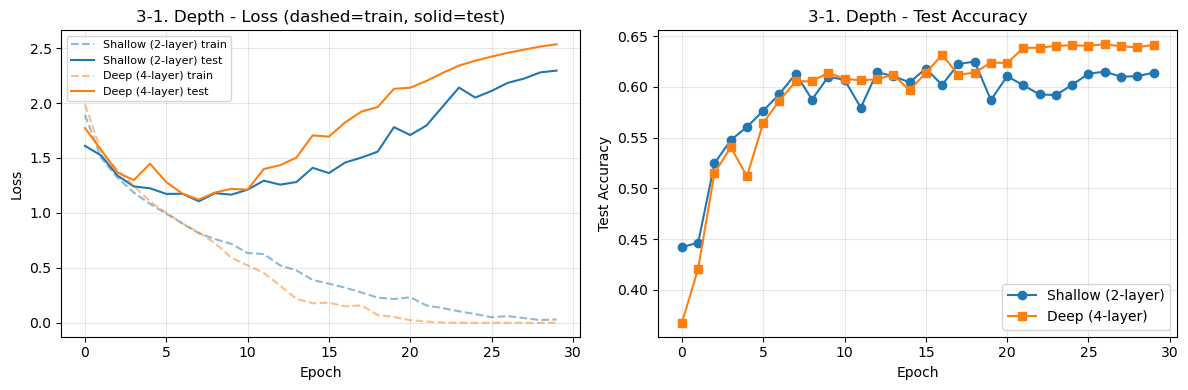

Shallow final acc: 0.6140  (peak: 0.6250)
Deep    final acc: 0.6415  (peak: 0.6420)


In [7]:
# 얕은 모델 학습
torch.manual_seed(42)
model_shallow = CNN_Shallow().to(device)
opt_shallow = torch.optim.SGD(model_shallow.parameters(), lr=0.01, momentum=0.9)
print(f'Training Shallow on {device}...')
r_shallow = train(model_shallow, train_loader, test_loader, opt_shallow, epochs=30, device=device)

# 깊은 모델 학습
torch.manual_seed(42)
model_deep = CNN_Deep().to(device)
opt_deep = torch.optim.SGD(model_deep.parameters(), lr=0.01, momentum=0.9)
print()
print(f'Training Deep (no BN, no Drop, Kaiming init) on {device}...')
r_deep = train(model_deep, train_loader, test_loader, opt_deep, epochs=30, device=device)

plot_compare(r_shallow, r_deep, 'Shallow (2-layer)', 'Deep (4-layer)', '3-1. Depth')
print(f'Shallow final acc: {r_shallow[2][-1]:.4f}  (peak: {max(r_shallow[2]):.4f})')
print(f'Deep    final acc: {r_deep[2][-1]:.4f}  (peak: {max(r_deep[2]):.4f})')


## 결과 고찰

깊은 모델이 얕은 모델보다 정확도가 약간 높지만 (+1~2%p), **과적합 정도는 훨씬 심합니다**.

위 학습 곡선의 **왼쪽 Loss 그래프**를 보세요. 깊은 모델의 train loss(점선)는 거의 0까지 떨어지는데 test loss(실선)는 계속 올라갑니다 — 모델의 표현력이 학습 데이터를 **외우는 데** 쓰이고 있다는 신호입니다.

즉 깊은 모델은 *잠재력은 큰데 학습 데이터에만 맞춰지는* 상태. 이 잠재력을 끌어내는 것이 다음 섹션의 목표입니다.

> - **3-2**: `BatchNorm2d` 로 학습 안정화 → 깊은 모델이 진짜로 도움이 됨
> - **3-3**: `Dropout` 으로 과적합 추가 억제


---
## 3-2. BatchNorm2d 효과: 깊은 vs 깊은 + BN

같은 깊은 구조에 **Conv-BN-ReLU 블록**을 적용합니다.

- **A**: 깊은 모델 (no BN) — 위 3-1의 `r_deep` 재사용
- **B**: 깊은 + BatchNorm2d

BN을 도입하면 학습이 더 안정적이고 빠르게 수렴합니다.


In [8]:
# 깊은 + BN (Kaiming init 포함)
class CNN_Deep_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.fc = nn.Linear(128 * 4 * 4, 10)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.flatten(1)
        x = self.fc(x)
        return x

print(f'Deep+BN params: {sum(p.numel() for p in CNN_Deep_BN().parameters()):,}')


Deep+BN params: 262,026


Training Deep + BN on cuda...


  Epoch  1/30  train_loss=1.5727  test_loss=1.5481  test_acc=0.4590


  Epoch  2/30  train_loss=1.1696  test_loss=1.4737  test_acc=0.5010


  Epoch  3/30  train_loss=0.9594  test_loss=1.2136  test_acc=0.5840


  Epoch  4/30  train_loss=0.7625  test_loss=1.2413  test_acc=0.5825


...

  Epoch 26/30  train_loss=0.0042  test_loss=1.3466  test_acc=0.6675


  Epoch 27/30  train_loss=0.0038  test_loss=1.3467  test_acc=0.6615


  Epoch 28/30  train_loss=0.0037  test_loss=1.3596  test_acc=0.6650


  Epoch 29/30  train_loss=0.0034  test_loss=1.3873  test_acc=0.6645


  Epoch 30/30  train_loss=0.0058  test_loss=1.3708  test_acc=0.6660


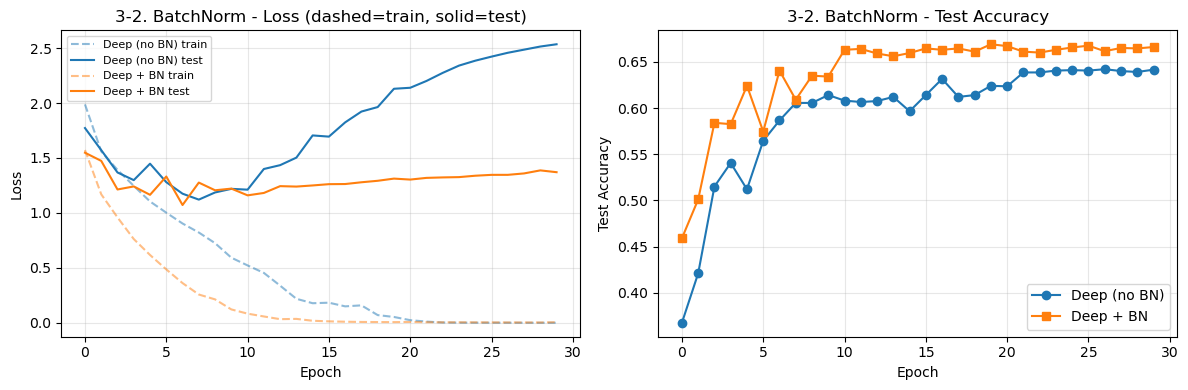

Deep      final acc: 0.6415  (peak: 0.6420)
Deep + BN final acc: 0.6660  (peak: 0.6690)


In [9]:
# 깊은 + BN 학습
torch.manual_seed(42)
model_deep_bn = CNN_Deep_BN().to(device)
opt_deep_bn = torch.optim.SGD(model_deep_bn.parameters(), lr=0.01, momentum=0.9)
print(f'Training Deep + BN on {device}...')
r_deep_bn = train(model_deep_bn, train_loader, test_loader, opt_deep_bn, epochs=30, device=device)

plot_compare(r_deep, r_deep_bn, 'Deep (no BN)', 'Deep + BN', '3-2. BatchNorm')
print(f'Deep      final acc: {r_deep[2][-1]:.4f}  (peak: {max(r_deep[2]):.4f})')
print(f'Deep + BN final acc: {r_deep_bn[2][-1]:.4f}  (peak: {max(r_deep_bn[2]):.4f})')


---
## 3-3. Dropout 효과: 깊은+BN vs 깊은+BN+Dropout

Dropout을 CNN에 적용. 보통 **FC 직전**에 넣습니다.

- **A**: 깊은+BN (Dropout 없음) — 위 3-2의 `r_deep_bn` 재사용
- **B**: 깊은+BN + Dropout(0.5)


In [10]:
# 깊은 + BN + Dropout
class CNN_Deep_BN_Drop(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128 * 4 * 4, 10)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

print(f'Deep+BN+Drop params: {sum(p.numel() for p in CNN_Deep_BN_Drop().parameters()):,}')


Deep+BN+Drop params: 262,026


Training Deep + BN + Dropout(0.5) on cuda...


  Epoch  1/30  train_loss=1.7155  test_loss=1.4812  test_acc=0.4815


  Epoch  2/30  train_loss=1.4418  test_loss=1.2662  test_acc=0.5490


  Epoch  3/30  train_loss=1.2390  test_loss=1.1748  test_acc=0.5775


  Epoch  4/30  train_loss=1.1027  test_loss=1.0801  test_acc=0.6350


...

  Epoch 26/30  train_loss=0.1159  test_loss=1.2746  test_acc=0.6790


  Epoch 27/30  train_loss=0.1151  test_loss=1.3300  test_acc=0.6780


  Epoch 28/30  train_loss=0.1046  test_loss=1.1829  test_acc=0.6865


  Epoch 29/30  train_loss=0.1133  test_loss=1.3313  test_acc=0.6755


  Epoch 30/30  train_loss=0.0926  test_loss=1.3329  test_acc=0.6715


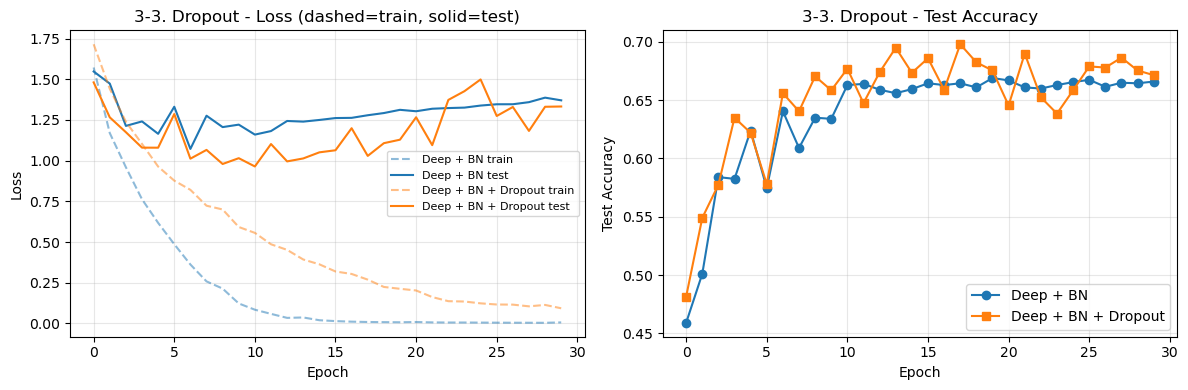

Deep + BN        final acc: 0.6660  (peak: 0.6690)
Deep + BN + Drop final acc: 0.6715  (peak: 0.6980)


In [11]:
# 깊은 + BN + Dropout 학습
torch.manual_seed(42)
model_deep_bn_drop = CNN_Deep_BN_Drop().to(device)
opt_deep_bn_drop = torch.optim.SGD(model_deep_bn_drop.parameters(), lr=0.01, momentum=0.9)
print(f'Training Deep + BN + Dropout(0.5) on {device}...')
r_deep_bn_drop = train(model_deep_bn_drop, train_loader, test_loader, opt_deep_bn_drop, epochs=30, device=device)

plot_compare(r_deep_bn, r_deep_bn_drop, 'Deep + BN', 'Deep + BN + Dropout', '3-3. Dropout')
print(f'Deep + BN        final acc: {r_deep_bn[2][-1]:.4f}  (peak: {max(r_deep_bn[2]):.4f})')
print(f'Deep + BN + Drop final acc: {r_deep_bn_drop[2][-1]:.4f}  (peak: {max(r_deep_bn_drop[2]):.4f})')


---
# 4. 데이터 증강 (Data Augmentation)

학습 시 매 epoch마다 입력에 **랜덤 변환**을 적용 → 사실상 데이터 양이 늘어나는 효과.

**전형적인 증강 (CIFAR-10 표준 조합):**
- `RandomCrop(32, padding=4)` — 가장자리 0 패딩 후 랜덤 위치 32x32 자르기
- `RandomHorizontalFlip(p=0.5)` — 50% 확률 좌우 반전 (자연 객체는 좌우 대칭)

**구현 방식**: 같은 Custom Dataset 템플릿에 transform만 다른 걸 끼웁니다. DataLoader가 매 배치마다 `__getitem__` 호출 → 매번 다른 랜덤 변환 자동 적용.

- **A**: Section 3-3 모델, **증강 없음** (= `r_deep_bn_drop`)
- **B**: 같은 모델, **RandomCrop + HFlip 적용**
- 같은 10000장 데이터, 같은 모델, 같은 epoch — 오직 transform만 다름

증강은 train set에만 적용 (test에는 안 함).


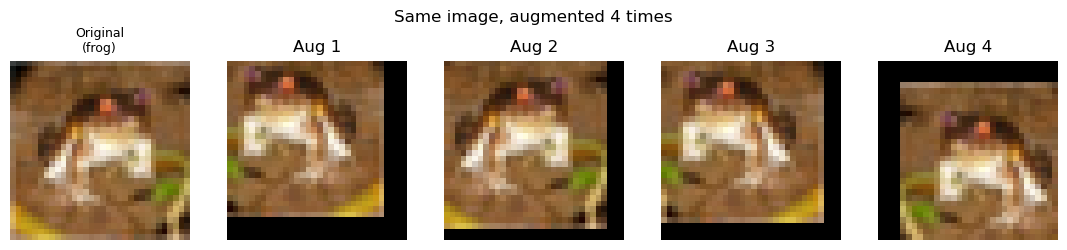

In [12]:
# 증강 transform — train용
transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 같은 X_train, y_train 에 transform_aug만 다르게 적용 (Custom Dataset 그대로 활용)
train_set_aug = CIFAR10Dataset(X_train, y_train, transform=transform_aug)
loader_aug = DataLoader(train_set_aug, batch_size=128, shuffle=True)

# 같은 이미지를 4번 호출해서 다른 augmentation 결과 확인
torch.manual_seed(0)
img_orig, label_orig = train_set[0]            # 증강 없음
fig, axes = plt.subplots(1, 5, figsize=(11, 2.5))
axes[0].imshow(unnormalize(img_orig))
axes[0].set_title(f'Original\n({class_names[label_orig]})', fontsize=9)
axes[0].axis('off')
for i in range(4):
    img_i, _ = train_set_aug[0]                 # 매번 다른 변환
    axes[i+1].imshow(unnormalize(img_i))
    axes[i+1].set_title(f'Aug {i+1}'); axes[i+1].axis('off')
plt.suptitle('Same image, augmented 4 times')
plt.tight_layout(); plt.show()


Training Deep+BN+Drop with Augmentation (10000 samples) on cuda...


  Epoch  1/30  train_loss=1.8896  test_loss=1.5979  test_acc=0.4050


  Epoch  2/30  train_loss=1.6889  test_loss=1.4590  test_acc=0.4875


  Epoch  3/30  train_loss=1.5870  test_loss=1.3746  test_acc=0.5160


  Epoch  4/30  train_loss=1.4594  test_loss=1.2244  test_acc=0.5620


...

  Epoch 26/30  train_loss=0.7837  test_loss=0.7755  test_acc=0.7280


  Epoch 27/30  train_loss=0.7758  test_loss=0.8371  test_acc=0.7080


  Epoch 28/30  train_loss=0.7546  test_loss=0.8950  test_acc=0.6930


  Epoch 29/30  train_loss=0.7615  test_loss=0.7729  test_acc=0.7385


  Epoch 30/30  train_loss=0.7177  test_loss=0.8204  test_acc=0.7135


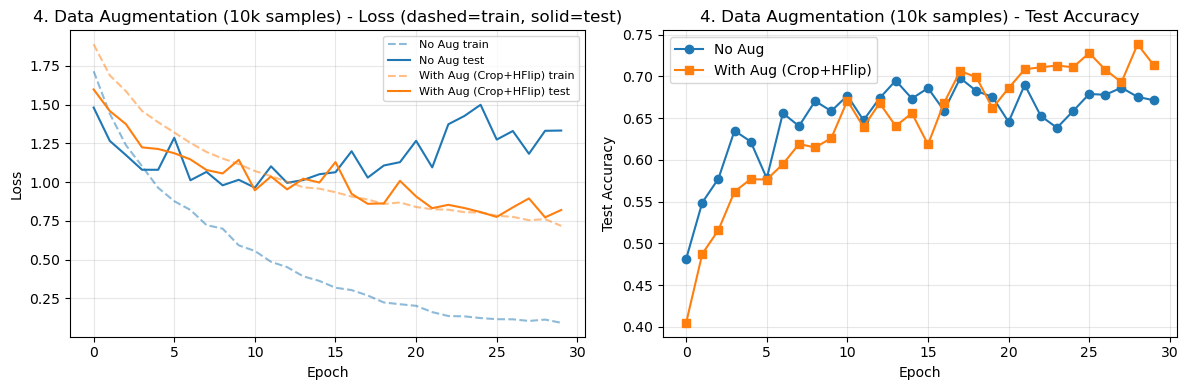

No Aug   final acc: 0.6715  (peak: 0.6980)
With Aug final acc: 0.7135  (peak: 0.7385)
-> 증강은 사실상 데이터 양을 늘리는 효과로 과적합을 억제합니다.


In [13]:
# B: 증강 적용 학습 (A = Section 3-3의 r_deep_bn_drop 재사용)
torch.manual_seed(42)
model_with_aug = CNN_Deep_BN_Drop().to(device)
opt_with_aug = torch.optim.SGD(model_with_aug.parameters(), lr=0.01, momentum=0.9)
print(f'Training Deep+BN+Drop with Augmentation (10000 samples) on {device}...')
r_with_aug = train(model_with_aug, loader_aug, test_loader, opt_with_aug, epochs=30, device=device)

plot_compare(r_deep_bn_drop, r_with_aug,
             'No Aug', 'With Aug (Crop+HFlip)', '4. Data Augmentation (10k samples)')
print(f'No Aug   final acc: {r_deep_bn_drop[2][-1]:.4f}  (peak: {max(r_deep_bn_drop[2]):.4f})')
print(f'With Aug final acc: {r_with_aug[2][-1]:.4f}  (peak: {max(r_with_aug[2]):.4f})')
print('-> 증강은 사실상 데이터 양을 늘리는 효과로 과적합을 억제합니다.')


---
# 5. Custom CNN 시각화 — 학습된 필터와 feature map

Section 3~4에서 학습한 `model_with_aug` (깊은+BN+Drop+Aug) 가 무엇을 학습했는지 들여다봅니다.

1. **첫 conv 레이어의 학습된 필터** — 작은 패턴 검출기 (3채널이라 RGB 컬러로 표시)
2. **첫 layer의 feature map** — `model.layer1(x)` 을 직접 호출해 중간 출력을 가져옴

우리 모델은 `self.layer1`, `self.layer2` 처럼 블록을 명시적으로 정의해 둔 덕에, 별도 hook 없이 `model.layer1(x)` 한 줄로 중간 출력을 얻을 수 있습니다.


Custom CNN first conv weight: (32, 3, 3, 3)  (out_ch, in_ch, K, K)


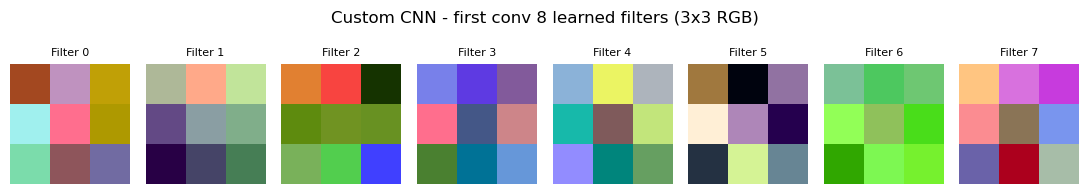

In [14]:
# Custom CNN (model_with_aug) 첫 conv 필터 8개 — Conv2d(3, 32, kernel_size=3)
first_conv_custom = model_with_aug.layer1[0]
filters_custom = first_conv_custom.weight.detach().cpu().numpy()  # (32, 3, 3, 3)
print(f'Custom CNN first conv weight: {filters_custom.shape}  (out_ch, in_ch, K, K)')

fig, axes = plt.subplots(1, 8, figsize=(11, 1.8))
for i in range(8):
    f = filters_custom[i].transpose(1, 2, 0)         # (3, 3, 3) - (H, W, C)
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)   # 표시용 [0, 1] 정규화
    axes[i].imshow(f)
    axes[i].set_title(f'Filter {i}', fontsize=8)
    axes[i].axis('off')
plt.suptitle('Custom CNN - first conv 8 learned filters (3x3 RGB)', y=1.05)
plt.tight_layout(); plt.show()


Feature map shape: (32, 16, 16)  (32 channels, 16x16)


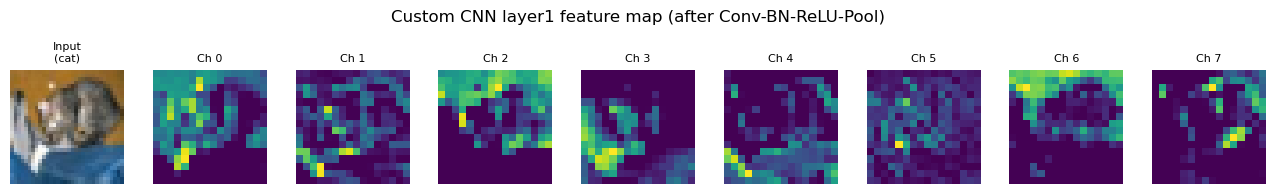

-> 학습 데이터 10000장 + from scratch 학습이라 필터/feature map이 다소 random-looking.
-> Section 6에서 ImageNet 사전학습 ResNet18 의 필터와 비교해 보면 차이가 극명합니다.


In [15]:
# Feature map 추출 — model.layer1(x) 한 줄로 중간 출력
img_sample, label_sample = test_set[0]
sample_d = img_sample.unsqueeze(0).to(device)        # (1, 3, 32, 32)

model_with_aug.eval()
with torch.no_grad():
    feat = model_with_aug.layer1(sample_d)           # (1, 32, 16, 16)

feat = feat.squeeze(0).cpu()                         # (32, 16, 16)
print(f'Feature map shape: {tuple(feat.shape)}  (32 channels, 16x16)')

# 입력 + 8개 채널 시각화
fig, axes = plt.subplots(1, 9, figsize=(13, 1.8))
axes[0].imshow(unnormalize(img_sample))
axes[0].set_title(f'Input\n({class_names[label_sample]})', fontsize=8)
axes[0].axis('off')
for i in range(8):
    axes[i+1].imshow(feat[i], cmap='viridis')
    axes[i+1].set_title(f'Ch {i}', fontsize=8)
    axes[i+1].axis('off')
plt.suptitle('Custom CNN layer1 feature map (after Conv-BN-ReLU-Pool)', y=1.05)
plt.tight_layout(); plt.show()

print('-> 학습 데이터 10000장 + from scratch 학습이라 필터/feature map이 다소 random-looking.')
print('-> Section 6에서 ImageNet 사전학습 ResNet18 의 필터와 비교해 보면 차이가 극명합니다.')


---
# 6. Pretrained ResNet18 fine-tuning

지금까지의 custom CNN(Section 3~4)은 ~73% 가 천장. **ImageNet 120만 장 사전학습된 ResNet18** 을 가져와 CIFAR-10 으로 fine-tuning 하면 단 5 epoch 만에 ~89% 도달합니다.

**핵심 관찰**:
- ResNet18 은 ImageNet **1000클래스용**. 마지막 FC를 `nn.Linear(512, 10)` 으로 교체 → 새 FC는 **random 초기값**
- 따라서 **학습 전 정확도는 ~10% (random)**
- 그러나 학습 **1 epoch만에 ~82% 점프** → 사전학습 backbone feature 의 강력함

| 항목 | 설정 |
|------|------|
| 모델 | Pretrained ResNet18 (FC 10-class로 교체, 전체 fine-tuning) |
| 데이터 | 같은 10000장 (Section 3~4와 동일) |
| 입력 크기 | Resize 96 (속도 절충) |
| Optimizer | SGD(lr=0.001, momentum=0.9) |
| Epoch | 5 |
| **결과** | **~89%** (custom CNN ~73% 대비 +16%p) |

> **CUDA 기준 약 30초**. CPU에서는 30분+ 걸리니 건너뛰기 권장.
>
> Resize를 224 대신 96으로 한 이유: 학습 시간 단축. ResNet18은 AdaptiveAvgPool 덕분에 입력 크기에 유연. 224를 쓰면 정확도가 90%+로 올라가지만 시간이 3배+ 증가.


In [18]:
# ImageNet 표준 정규화 통계 (Pretrained ResNet18 학습에 사용)
IMNET_MEAN = (0.485, 0.456, 0.406)
IMNET_STD  = (0.229, 0.224, 0.225)

# transform — Resize(96), ImageNet 표준 정규화, train에 좌우반전 증강
transform_imnet_train = transforms.Compose([
    transforms.Resize(96),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN, IMNET_STD),
])
transform_imnet_test = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor(),
    transforms.Normalize(IMNET_MEAN, IMNET_STD),
])

# 같은 10000장 / 2000장, ImageNet 전처리 transform 적용
trainset_imnet = CIFAR10Dataset(X_train, y_train, transform=transform_imnet_train)
testset_imnet  = CIFAR10Dataset(X_test,  y_test,  transform=transform_imnet_test)

trainloader_imnet = DataLoader(trainset_imnet, batch_size=64, shuffle=True)
testloader_imnet  = DataLoader(testset_imnet,  batch_size=128, shuffle=False)

print(f'Train: {len(trainset_imnet)} samples (96x96 resized)')
print(f'Test : {len(testset_imnet)} samples')

Train: 10000 samples (96x96 resized)
Test : 2000 samples


In [19]:
from torchvision.models import resnet18, ResNet18_Weights

# Pretrained ResNet18 — 마지막 FC를 10-class로 교체, 전체 fine-tuning
resnet_full = resnet18(weights=ResNet18_Weights.DEFAULT)
resnet_full.fc = nn.Linear(resnet_full.fc.in_features, 10)
resnet_full = resnet_full.to(device)

n_total = sum(p.numel() for p in resnet_full.parameters())
n_train = sum(p.numel() for p in resnet_full.parameters() if p.requires_grad)
print(f'Total / Trainable params: {n_total:,} / {n_train:,}  (전체 fine-tuning)')

# 학습 전 baseline — FC가 random 초기값이므로 chance level(~10%) 예상
_, acc_before = evaluate(resnet_full, testloader_imnet, device)
print()
print(f'[Before fine-tuning] test accuracy = {acc_before:.4f}  (random FC, ~10% 예상)')


Total / Trainable params: 11,181,642 / 11,181,642  (전체 fine-tuning)



[Before fine-tuning] test accuracy = 0.0715  (random FC, ~10% 예상)


In [20]:
# SGD + momentum (full fine-tuning에 적합)
opt_full = torch.optim.SGD(resnet_full.parameters(), lr=0.001, momentum=0.9)

import time
print()
print(f'Full fine-tuning ResNet18 on CIFAR-10 (10000 samples, 96x96) on {device}...')
t0 = time.time()
r_resnet_full = train(resnet_full, trainloader_imnet, testloader_imnet, opt_full, epochs=5, device=device)
elapsed = time.time() - t0
print()
print(f'Elapsed: {elapsed:.1f}s on {device}')
print(f'Final test accuracy: {r_resnet_full[2][-1]:.4f}  (peak: {max(r_resnet_full[2]):.4f})')
print(f'-> 학습 전 {acc_before:.4f} → epoch 1 후 {r_resnet_full[2][0]:.4f} → epoch 5 후 {r_resnet_full[2][-1]:.4f}')



Full fine-tuning ResNet18 on CIFAR-10 (10000 samples, 96x96) on cuda...


  Epoch  1/5  train_loss=0.9849  test_loss=0.5090  test_acc=0.8120


  Epoch  2/5  train_loss=0.3841  test_loss=0.4257  test_acc=0.8485


  Epoch  3/5  train_loss=0.2637  test_loss=0.3606  test_acc=0.8700


  Epoch  4/5  train_loss=0.1899  test_loss=0.3499  test_acc=0.8715


  Epoch  5/5  train_loss=0.1375  test_loss=0.3039  test_acc=0.8940

Elapsed: 24.0s on cuda
Final test accuracy: 0.8940  (peak: 0.8940)
-> 학습 전 0.0715 → epoch 1 후 0.8120 → epoch 5 후 0.8940


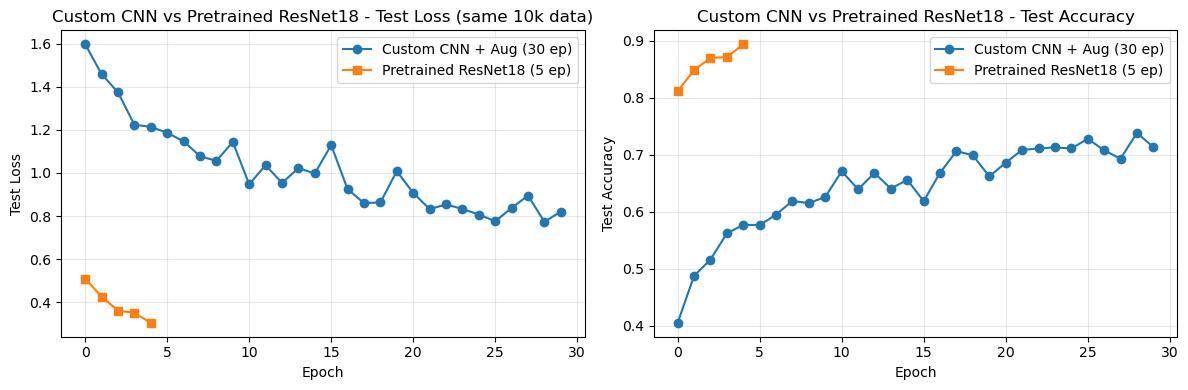

Custom CNN + Aug   peak: 0.7385
Pretrained ResNet18 peak: 0.8940
-> 같은 10000장, 사전학습 ResNet18은 5 epoch만에 Custom CNN 30 epoch 결과 능가.


In [21]:
# 같은 10000장 데이터에서: Custom CNN (Section 4, 30 ep) vs Pretrained ResNet18 (Section 6-2, 5 ep)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(r_with_aug[1], 'o-', label='Custom CNN + Aug (30 ep)')
axes[0].plot(r_resnet_full[1], 's-', label='Pretrained ResNet18 (5 ep)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Loss')
axes[0].set_title('Custom CNN vs Pretrained ResNet18 - Test Loss (same 10k data)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(r_with_aug[2], 'o-', label='Custom CNN + Aug (30 ep)')
axes[1].plot(r_resnet_full[2], 's-', label='Pretrained ResNet18 (5 ep)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Custom CNN vs Pretrained ResNet18 - Test Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Custom CNN + Aug   peak: {max(r_with_aug[2]):.4f}')
print(f'Pretrained ResNet18 peak: {max(r_resnet_full[2]):.4f}')
print(f'-> 같은 10000장, 사전학습 ResNet18은 5 epoch만에 Custom CNN 30 epoch 결과 능가.')


---
# 7. ResNet18 시각화 — 사전학습 필터는 어떻게 생겼나

Section 5의 Custom CNN 필터는 random-looking 패턴이었습니다. 같은 방식으로 사전학습 ResNet18 의 첫 conv 필터를 보면, **색·방향성 엣지 검출기** 모양이 명확히 드러납니다 — 교과서·논문에 자주 등장하는 그 패턴.

| 모델 | 첫 conv | 학습 방식 | 필터 모양 |
|------|---------|----------|----------|
| Custom CNN (Section 5) | Conv2d(3, 32, k=3) | 10000장 CIFAR from scratch | random-looking |
| **Pretrained ResNet18** | Conv2d(3, 64, k=7) | **ImageNet 120만장** + CIFAR fine-tune | **edge/color detector** |


ResNet18 first conv weight: (64, 3, 7, 7)  (out_ch, in_ch, K, K)


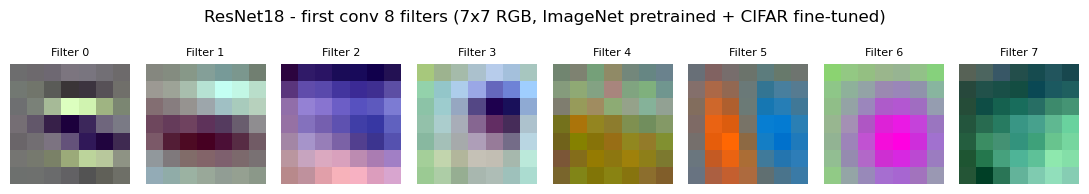

-> Section 5의 Custom CNN 필터(random-looking)와 비교해 보세요.
-> 색·방향성 엣지 검출기 패턴이 명확. ImageNet 120만장 사전학습의 효과.


In [22]:
# Pretrained ResNet18 첫 conv 필터 8개 — Conv2d(3, 64, kernel_size=7)
first_conv_resnet = resnet_full.conv1
filters_resnet = first_conv_resnet.weight.detach().cpu().numpy()  # (64, 3, 7, 7)
print(f'ResNet18 first conv weight: {filters_resnet.shape}  (out_ch, in_ch, K, K)')

fig, axes = plt.subplots(1, 8, figsize=(11, 1.8))
for i in range(8):
    f = filters_resnet[i].transpose(1, 2, 0)         # (7, 7, 3)
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    axes[i].imshow(f)
    axes[i].set_title(f'Filter {i}', fontsize=8)
    axes[i].axis('off')
plt.suptitle('ResNet18 - first conv 8 filters (7x7 RGB, ImageNet pretrained + CIFAR fine-tuned)', y=1.05)
plt.tight_layout(); plt.show()

print('-> Section 5의 Custom CNN 필터(random-looking)와 비교해 보세요.')
print('-> 색·방향성 엣지 검출기 패턴이 명확. ImageNet 120만장 사전학습의 효과.')


Custom CNN layer1 output: (32, 16, 16)  (32 channels, 16x16)
ResNet18    conv1  output: (64, 48, 48)  (64 channels, 48x48)


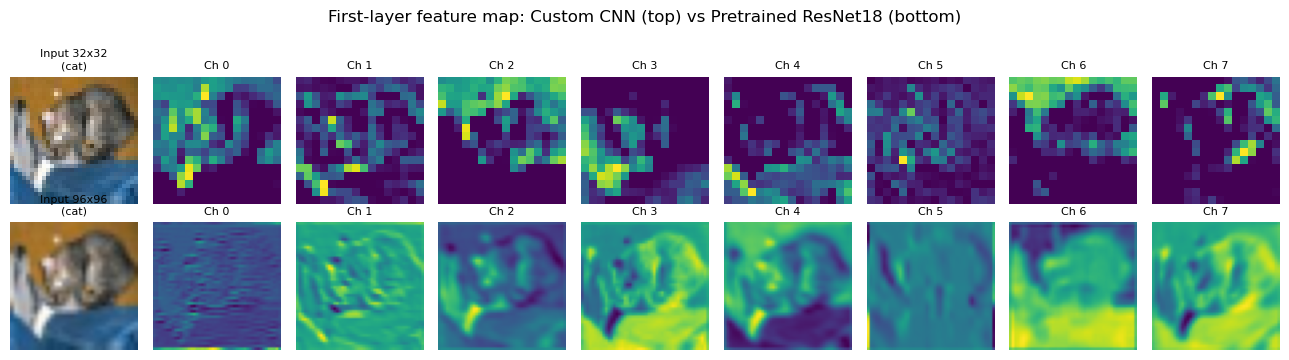

-> ResNet18은 채널 64개로 더 다양한 특징(엣지/색/패턴)을 동시에 검출.
-> Custom CNN은 32채널 + 작은 데이터로 학습 → 패턴이 덜 구조적.


In [23]:
# Feature map 비교 — 같은 입력에 두 모델의 첫 layer 출력
# Custom CNN용 입력 (32x32) + ResNet용 입력 (96x96) 둘 다 같은 인덱스
img_sample_custom, label_sample = test_set[0]            # (3, 32, 32), CIFAR 정규화
img_sample_resnet, _            = testset_imnet[0]       # (3, 96, 96), ImageNet 정규화

# Custom CNN feature map (Section 5에서 이미 확인했으나 비교를 위해 다시)
model_with_aug.eval()
with torch.no_grad():
    feat_custom = model_with_aug.layer1(img_sample_custom.unsqueeze(0).to(device))
feat_custom = feat_custom.squeeze(0).cpu()               # (32, 16, 16)

# ResNet18 feature map (conv1 통과 후)
resnet_full.eval()
with torch.no_grad():
    feat_resnet = resnet_full.conv1(img_sample_resnet.unsqueeze(0).to(device))
feat_resnet = feat_resnet.squeeze(0).cpu()               # (64, 48, 48)

print(f'Custom CNN layer1 output: {tuple(feat_custom.shape)}  (32 channels, 16x16)')
print(f'ResNet18    conv1  output: {tuple(feat_resnet.shape)}  (64 channels, 48x48)')

# ImageNet 정규화 되돌리기
def unnormalize_imnet(img_t):
    img = img_t.permute(1, 2, 0).numpy() * imnet_std + imnet_mean
    return np.clip(img, 0, 1)

# 2행 비교 — 각 행: 입력 + 8개 채널
fig, axes = plt.subplots(2, 9, figsize=(13, 3.5))

# Row 1 — Custom CNN
axes[0, 0].imshow(unnormalize(img_sample_custom))
axes[0, 0].set_title(f'Input 32x32\n({class_names[label_sample]})', fontsize=8)
axes[0, 0].axis('off')
for i in range(8):
    axes[0, i+1].imshow(feat_custom[i], cmap='viridis')
    axes[0, i+1].set_title(f'Ch {i}', fontsize=8)
    axes[0, i+1].axis('off')

# Row 2 — ResNet18
axes[1, 0].imshow(unnormalize_imnet(img_sample_resnet))
axes[1, 0].set_title(f'Input 96x96\n({class_names[label_sample]})', fontsize=8)
axes[1, 0].axis('off')
for i in range(8):
    axes[1, i+1].imshow(feat_resnet[i], cmap='viridis')
    axes[1, i+1].set_title(f'Ch {i}', fontsize=8)
    axes[1, i+1].axis('off')

plt.suptitle('First-layer feature map: Custom CNN (top) vs Pretrained ResNet18 (bottom)', y=1.02)
plt.tight_layout(); plt.show()

print('-> ResNet18은 채널 64개로 더 다양한 특징(엣지/색/패턴)을 동시에 검출.')
print('-> Custom CNN은 32채널 + 작은 데이터로 학습 → 패턴이 덜 구조적.')


---
# 8. 정리

| 기법 | 효과 | 본 노트북 결과 (CIFAR-10) |
|------|------|--------------------------|
| **깊이 (Deep)** | 표현력 증가, 단독으론 과적합 위험 | Shallow와 비슷 (BN/Drop 필요) |
| **BatchNorm2d** | 학습 안정화, 더 빠른 수렴 | **명확한 향상** |
| **Dropout (0.5)** | 과적합 감소, 일반화 향상 | 향상 |
| **Data Augmentation** | 사실상 데이터 증가, 일반화 향상 | **명확한 향상** |
| **Custom CNN 시각화 (Section 5)** | 학습된 패턴 직관적 확인 | 3x3 random-looking 필터 |
| **Pretrained + Fine-tuning (Section 6)** | ImageNet 120만 장 학습 backbone 재활용 | **~89%** (custom CNN 대비 +16%p, 단 5 epoch) |
| **ResNet18 시각화 (Section 7)** | 사전학습 필터는 어떻게 생겼나 | 7x7 edge/color detector (Gabor 모양) |


---
### 연습 문제

1. Section 3-3 의 `Dropout(0.5)` 을 `Dropout(0.3)` 으로 낮추면 효과가 어떻게 달라지나요?
2. Section 6 의 `ResNet18` 을 `resnet34`, `mobilenet_v2` 등으로 바꿔 정확도를 비교해 보세요.
3. 자신의 사진을 `data/my_photos/<클래스명>/<파일.jpg>` 형태로 저장하고 (ImageFolder 패턴 + Section 6 의 ResNet18 fine-tuning 코드를 그대로 응용해 학습해 보세요.


In [24]:
# 연습 문제 풀이 공간
